In [1]:
import ingestion.data_paths as data_paths
import ingestion.kilosort_data_import as kdi
import video.tracking_import as ti

animal_id = "613"
session_id = "20251210"
# kilosort_path = data_paths.get_kilosort_path(animal_id, session_id)
# kilosort_data = kdi.KilosortData(kilosort_path)


tracking_path = data_paths.get_tracking_files_by_date(session_id)[0]
tracking_df = ti.load_tracking_data(tracking_path)
animals_dict = ti.parse_tracking(tracking_df)

Searching for tracking files in \\nearline\karpova\TervoLab\analysis\Tracking\manual_tracking\cohort7 with date '20251210' and extensions ['.csv', '.h5', '.hdf5', '.mat', '.pkl', '.npz', '.json', '.txt']
Successfully loaded tracking data: 862048 rows, 13 columns
Parsed object '613': 71842 rows, 11 columns
Parsed object '615': 71843 rows, 11 columns
Parsed object '616': 71804 rows, 11 columns
Parsed object '617': 71841 rows, 11 columns
Parsed object '620': 71841 rows, 11 columns
Parsed object '621': 71836 rows, 11 columns
Parsed object '629': 71829 rows, 11 columns
Parsed object '630': 71845 rows, 11 columns
Parsed object '631': 71844 rows, 11 columns
Parsed object '634': 71843 rows, 11 columns
Parsed object '633': 71839 rows, 11 columns
Parsed object '635': 71841 rows, 11 columns


Plotted path for 613: 71842 points, 31560.2 pixels total distance
Plotted paths for 12 animals
Created heatmap for 613: 71842 data points
Created territorial occupancy map for 12 animals
  613: 152 territorial bins (1.5%)
  615: 90 territorial bins (0.9%)
  616: 137 territorial bins (1.4%)
  617: 256 territorial bins (2.6%)
  620: 46 territorial bins (0.5%)
  621: 69 territorial bins (0.7%)
  629: 198 territorial bins (2.0%)
  630: 34 territorial bins (0.3%)
  631: 203 territorial bins (2.0%)
  634: 187 territorial bins (1.9%)
  633: 183 territorial bins (1.8%)
  635: 224 territorial bins (2.2%)
Created occupancy-based Voronoi territorial diagram with 2467 seed points from 12 animals
  613: 193 seed points, 193 high-occupancy bins, 71842 total frames
  615: 122 seed points, 122 high-occupancy bins, 71843 total frames
  616: 193 seed points, 193 high-occupancy bins, 71804 total frames
  617: 297 seed points, 297 high-occupancy bins, 71841 total frames
  620: 68 seed points, 68 high-occu

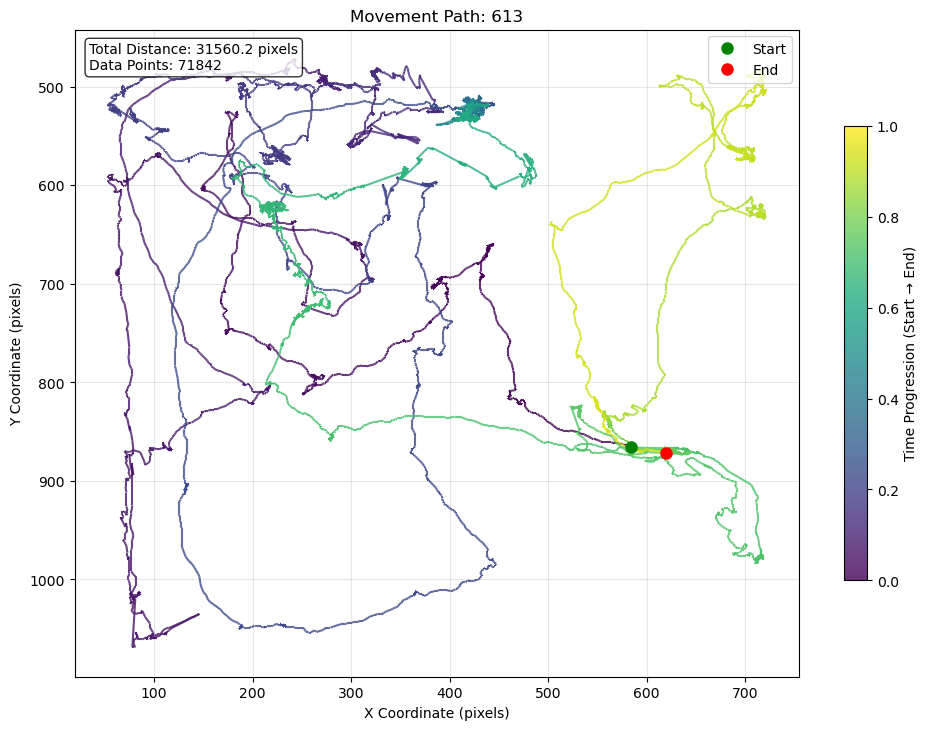

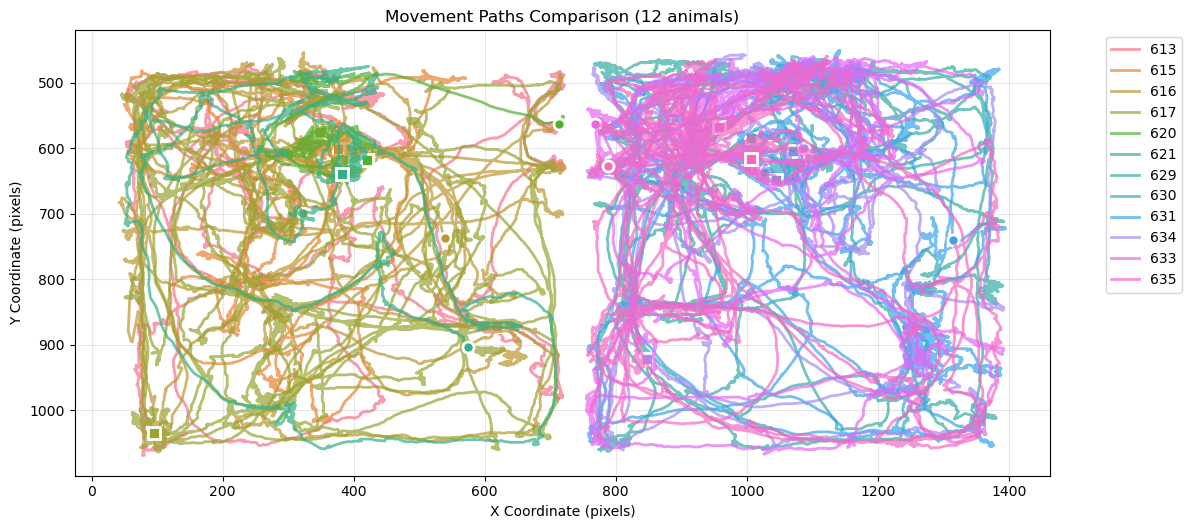

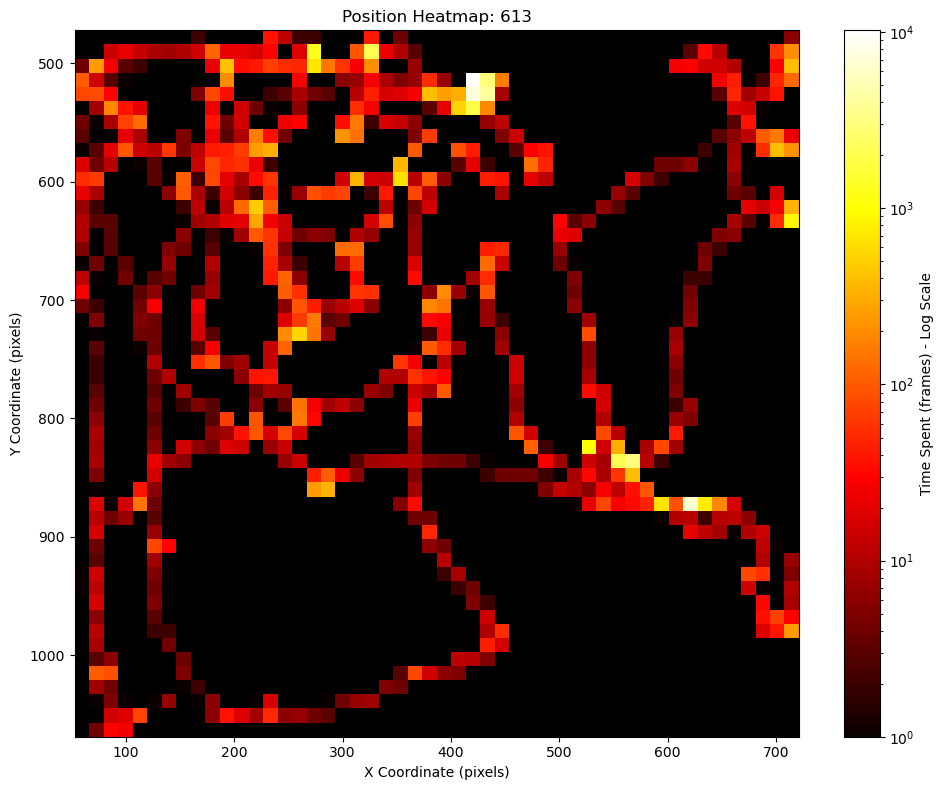

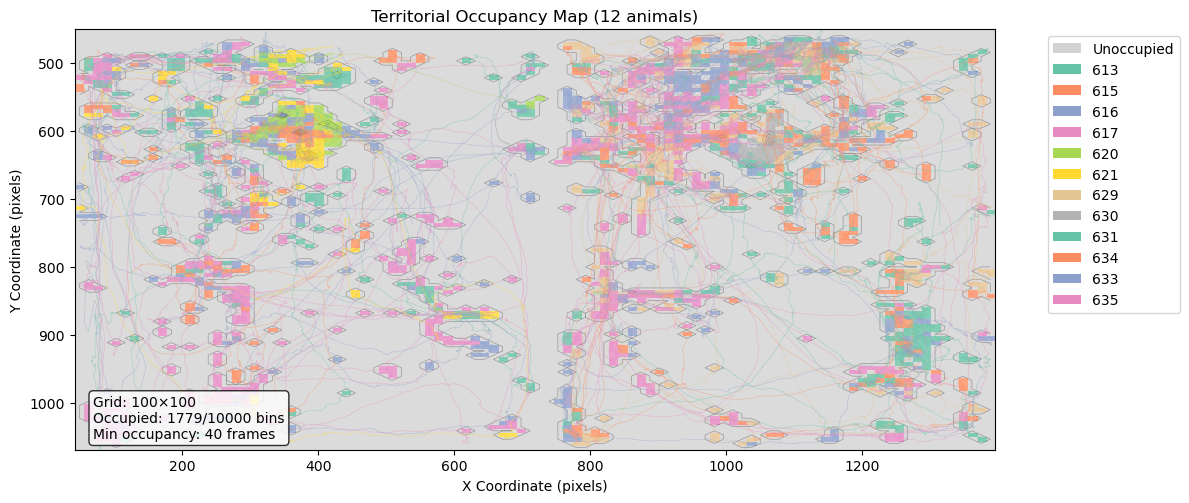

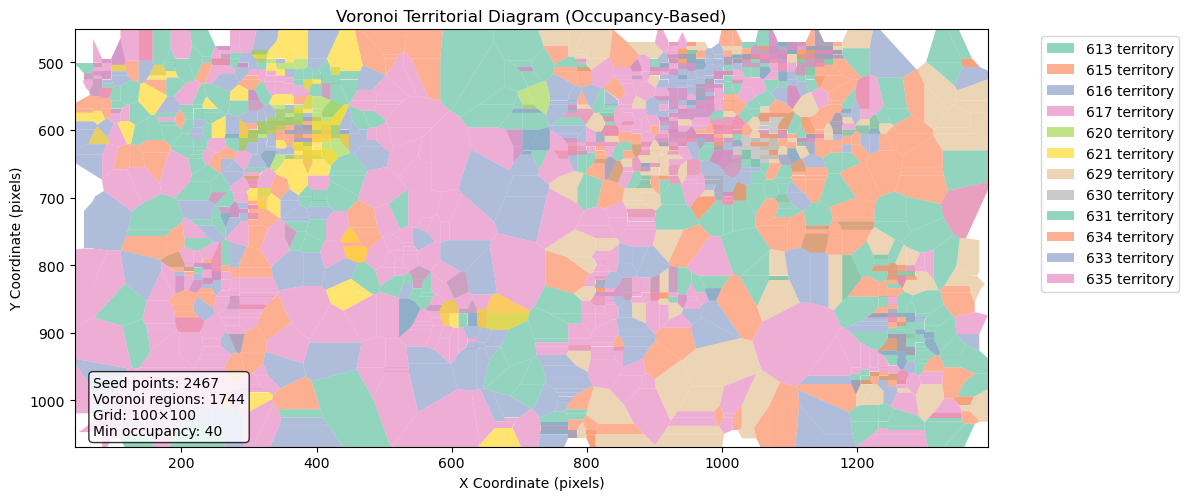

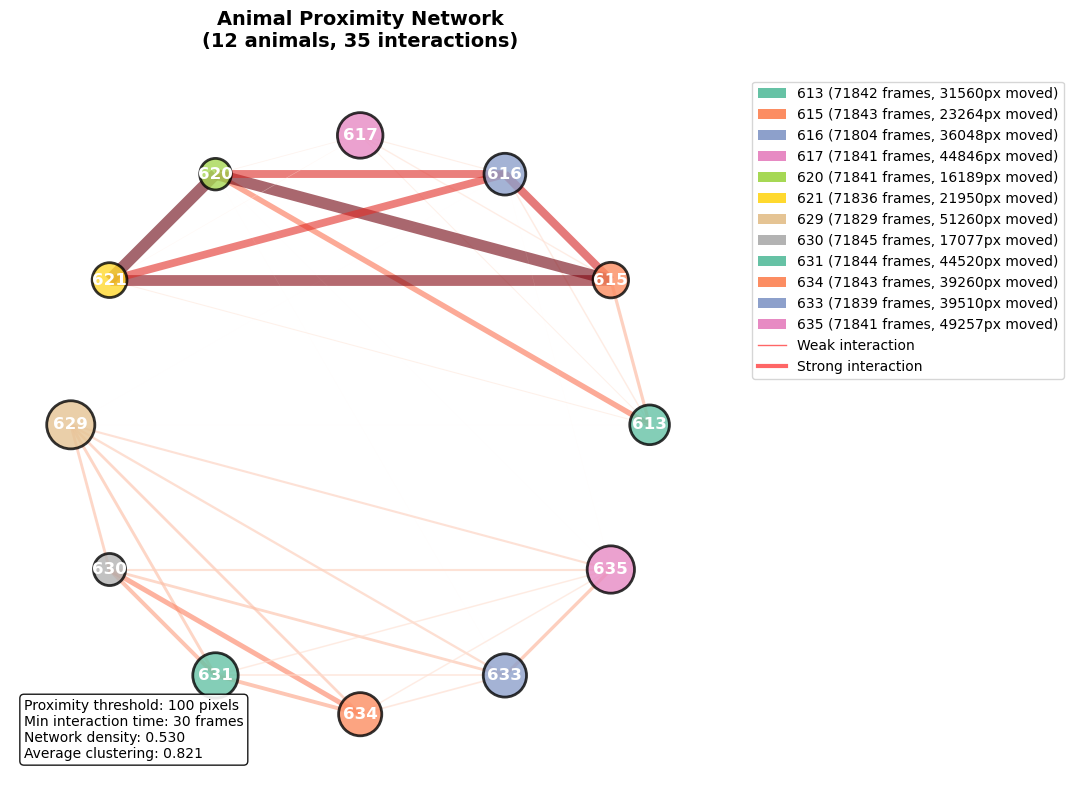

In [2]:
import video.plot_trajectory as path_viz
import importlib
importlib.reload(path_viz)
fig1 = path_viz.plot_animal_path(animals_dict['613'], "613")
fig2 = path_viz.plot_multiple_paths(animals_dict)
fig3 = path_viz.plot_path_heatmap(animals_dict['613'], "613")

# Create territorial map
fig4 = path_viz.plot_territorial_occupancy(
    tracking_dict=animals_dict,
    bins=100,  # High resolution
    min_occupancy=40  # Require 40+ frames to claim territory
)
# Create Voronoi territorial diagram
fig = path_viz.plot_voronoi_territories(
    tracking_dict=animals_dict,
    bins=100,  # Higher resolution
    min_occupancy=40,  # Only areas with 40+ frames
    alpha=0.7
)
fig = path_viz.plot_proximity_network(
    tracking_dict=animals_dict,
    proximity_threshold=100,  # Pixels
    layout_type='circular'  # 'circular', 'spring', 'kamada_kawai'
    # animals=['631', '634','613']  # Specify animals to include
)